# Exploratory Data Analysis  -  Diabetes 130-US Hospitals

**Objective:** Understand the drivers of 30-day readmission through systematic exploration of the cleaned dataset. Every analysis here is framed against the business question: *which patient and encounter characteristics predict readmission?*

**Notebook flow:**
1. Setup & Load
2. Target Distribution & Class Imbalance
3. Prior Utilisation (strongest signal)
4. Demographic Profile
5. Admission & Discharge Patterns
6. Clinical Complexity
7. Diabetes Medication Management
8. Key Findings Summary & Modelling Implications

---
## 1. Setup & Load

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── consistent plot style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
})

BLUE   = '#2E86AB'
RED    = '#E84855'
GRAY   = '#6C757D'
GREEN  = '#52B788'
ORANGE = '#F4A261'

df = pd.read_csv('../Dataset/cleaned/cleaned_data.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Positive class (readmitted <30d): {df['readmitted_binary'].sum():,}  ({df['readmitted_binary'].mean()*100:.1f}%)")

Dataset loaded: 101,766 rows × 47 columns
Positive class (readmitted <30d): 11,357  (11.2%)


---
## 2. Target Distribution & Class Imbalance

The first step is to quantify the class imbalance. With only 11.2% positive class, accuracy is a misleading metric  -  a model predicting "never readmitted" would be 88.8% accurate. **Recall and ROC-AUC are the correct primary metrics.**

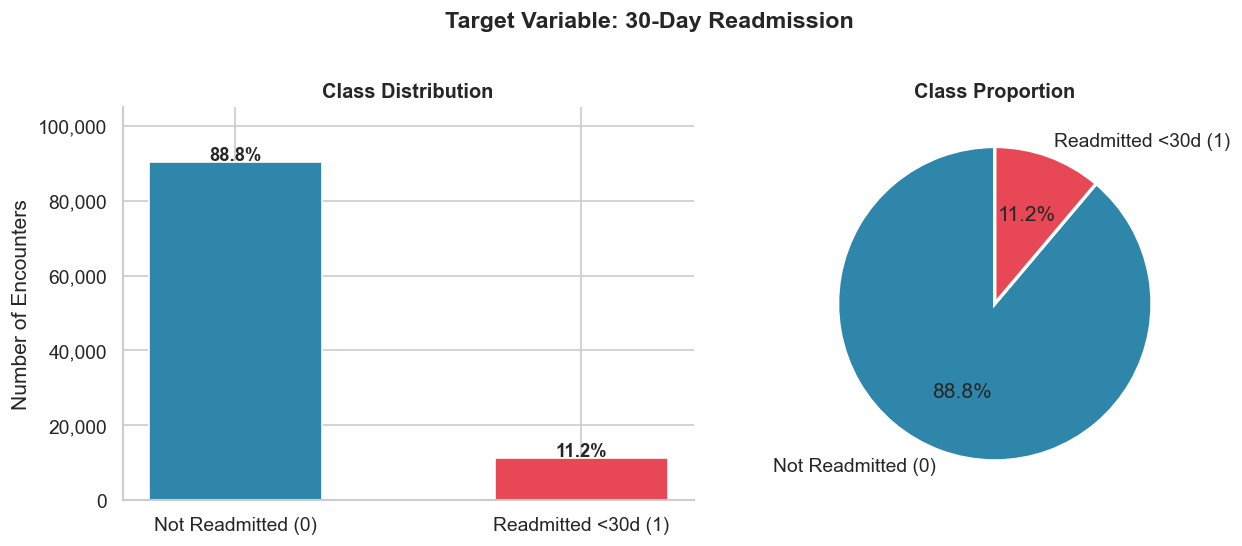

Not Readmitted :  90,409  (88.8%)
Readmitted <30d:  11,357  (11.2%)

Imbalance ratio: 8.0:1
→ Modelling note: use class_weight='balanced', SMOTE, or threshold tuning.


In [2]:
# ── Class balance ─────────────────────────────────────────────────────────────
counts = df['readmitted_binary'].value_counts()
labels = ['Not Readmitted (0)', 'Readmitted <30d (1)']
pcts   = [counts[0]/len(df)*100, counts[1]/len(df)*100]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Bar chart
bars = axes[0].bar(labels, [counts[0], counts[1]], color=[BLUE, RED], width=0.5, edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Encounters')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 105000)

# Pie
axes[1].pie([counts[0], counts[1]], labels=labels, colors=[BLUE, RED],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable: 30-Day Readmission', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Not Readmitted : {counts[0]:>7,}  ({pcts[0]:.1f}%)")
print(f"Readmitted <30d: {counts[1]:>7,}  ({pcts[1]:.1f}%)")
print(f"\nImbalance ratio: {counts[0]/counts[1]:.1f}:1")
print("→ Modelling note: use class_weight='balanced', SMOTE, or threshold tuning.")

---
## 3. Prior Utilisation  -  The Strongest Signal

Prior healthcare utilisation (past inpatient stays, emergency visits) is consistently the strongest predictor of future readmission. Patients who have been hospitalised before are more likely to be hospitalised again  -  whether due to disease severity, poor social support, or suboptimal discharge planning.

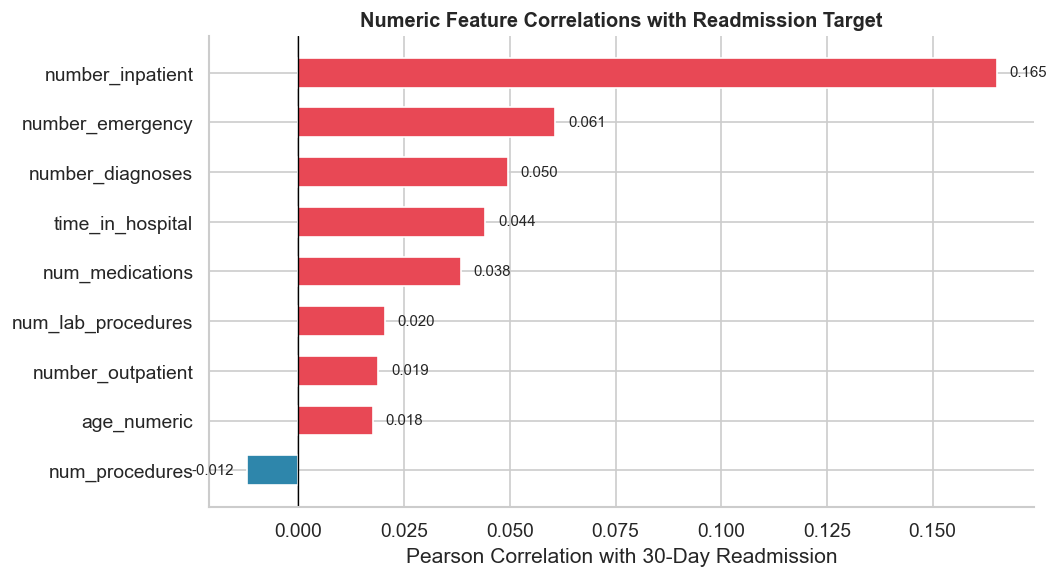

Key insight: number_inpatient (prior inpatient stays) has 4× the correlation
of any other numeric feature  -  it is the dominant predictive signal.


In [3]:
# ── Correlation of numeric features with target ───────────────────────────────
num_cols = ['number_inpatient', 'number_emergency', 'number_diagnoses',
            'time_in_hospital', 'num_medications', 'num_lab_procedures',
            'number_outpatient', 'age_numeric', 'num_procedures']

corrs = df[num_cols + ['readmitted_binary']].corr()['readmitted_binary'].drop('readmitted_binary')
corrs = corrs.sort_values(ascending=True)

colors = [RED if v > 0 else BLUE for v in corrs]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corrs.index, corrs.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with 30-Day Readmission')
ax.set_title('Numeric Feature Correlations with Readmission Target')

for bar, val in zip(bars, corrs.values):
    xpos = val + 0.003 if val >= 0 else val - 0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

print("Key insight: number_inpatient (prior inpatient stays) has 4× the correlation")
print("of any other numeric feature  -  it is the dominant predictive signal.")

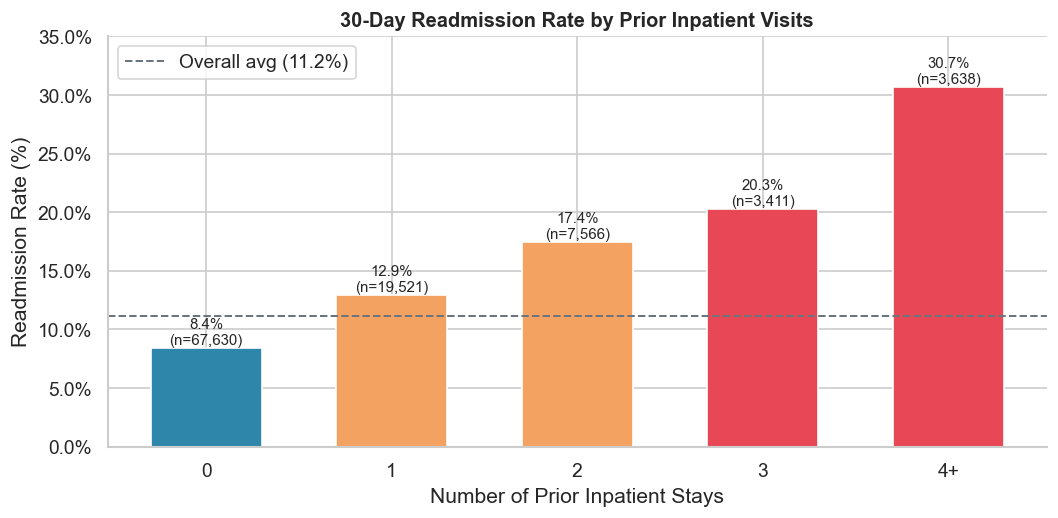

In [4]:
# ── Readmission rate by number of prior inpatient visits ──────────────────────
df['inpatient_group'] = pd.cut(df['number_inpatient'],
                                bins=[-1, 0, 1, 2, 3, 100],
                                labels=['0', '1', '2', '3', '4+'])

inp_rate = df.groupby('inpatient_group', observed=True)['readmitted_binary'].agg(['mean','count']).reset_index()
inp_rate.columns = ['group', 'readmit_rate', 'count']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(inp_rate['group'], inp_rate['readmit_rate']*100,
              color=[BLUE, ORANGE, ORANGE, RED, RED], edgecolor='white', width=0.6)
ax.axhline(df['readmitted_binary'].mean()*100, color=GRAY, linestyle='--', linewidth=1.2, label=f"Overall avg ({df['readmitted_binary'].mean()*100:.1f}%)")
ax.set_xlabel('Number of Prior Inpatient Stays')
ax.set_ylabel('Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Prior Inpatient Visits')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for bar, row in zip(bars, inp_rate.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row.readmit_rate*100:.1f}%\n(n={row.count:,})', ha='center', fontsize=9)
ax.set_ylim(0, 35)

plt.tight_layout()
plt.show()

In [5]:
# ── Mean utilisation metrics: readmitted vs not ────────────────────────────────
metrics = {
    'Prior Inpatient Stays':  'number_inpatient',
    'Prior ER Visits':        'number_emergency',
    'Time in Hospital (days)':'time_in_hospital',
    'Num Medications':        'num_medications',
    'Num Diagnoses':          'number_diagnoses',
    'Lab Procedures':         'num_lab_procedures',
}

summary = pd.DataFrame({
    name: df.groupby('readmitted_binary')[col].mean()
    for name, col in metrics.items()
}).T
summary.columns = ['Not Readmitted', 'Readmitted <30d']
summary['Difference'] = summary['Readmitted <30d'] - summary['Not Readmitted']
summary['% Difference'] = (summary['Difference'] / summary['Not Readmitted'] * 100).round(1)

print("Mean utilisation metrics by readmission status:")
print(summary.round(3).to_string())

Mean utilisation metrics by readmission status:
                         Not Readmitted  Readmitted <30d  Difference  % Difference
Prior Inpatient Stays             0.562            1.224       0.662         117.9
Prior ER Visits                   0.178            0.357       0.180         101.0
Time in Hospital (days)           4.349            4.768       0.419           9.6
Num Medications                  15.911           16.903       0.992           6.2
Num Diagnoses                     7.389            7.693       0.304           4.1
Lab Procedures                   42.954           44.226       1.272           3.0


> **Finding:** Readmitted patients have **2.2× more prior inpatient stays** and **2.0× more prior ER visits** than non-readmitted patients. These are by far the strongest individual predictors. Longer hospital stays and higher medication burden show much weaker separation.

---
## 4. Demographic Profile

Demographics provide context and may interact with clinical variables. The key question is whether any demographic group shows meaningfully different readmission rates  -  differences that could indicate care gaps rather than pure disease burden.

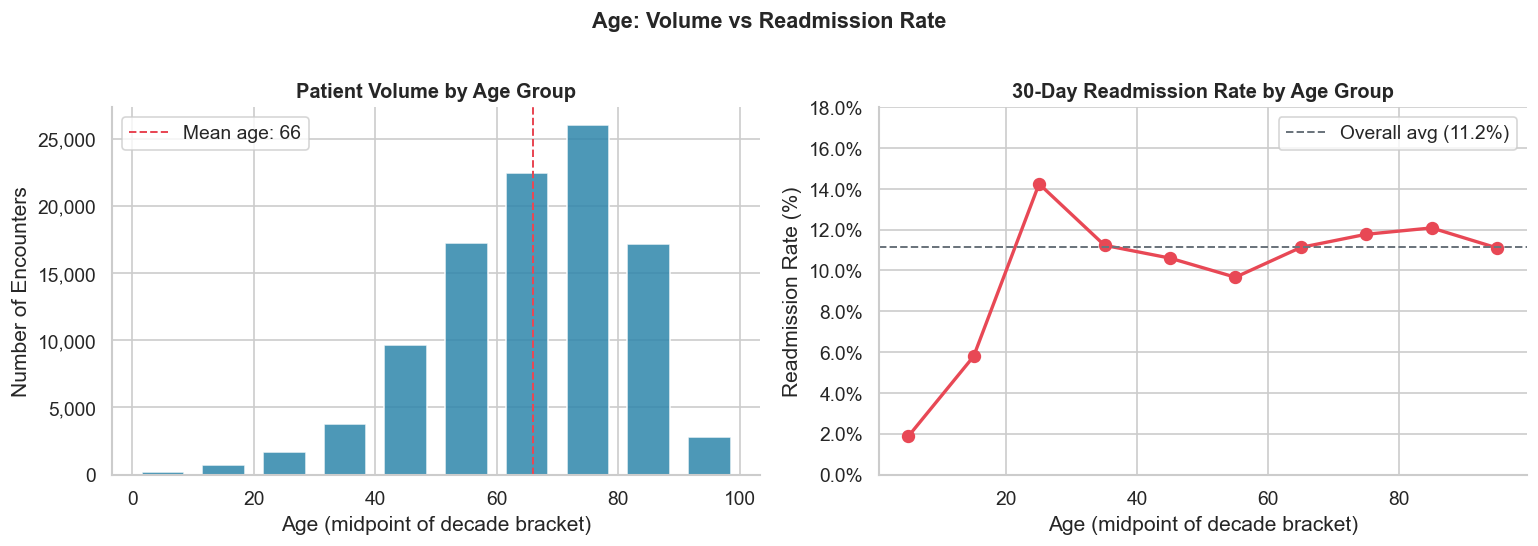

In [6]:
# ── Age distribution ──────────────────────────────────────────────────────────
age_rate = df.groupby('age_numeric')['readmitted_binary'].agg(['mean','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Volume distribution
axes[0].bar(age_rate['age_numeric'], age_rate['count'], width=7,
            color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Age (midpoint of decade bracket)')
axes[0].set_ylabel('Number of Encounters')
axes[0].set_title('Patient Volume by Age Group')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].axvline(df['age_numeric'].mean(), color=RED, linestyle='--', linewidth=1.2,
                label=f"Mean age: {df['age_numeric'].mean():.0f}")
axes[0].legend()

# Readmission rate by age
axes[1].plot(age_rate['age_numeric'], age_rate['mean']*100, marker='o',
             color=RED, linewidth=2, markersize=7)
axes[1].axhline(df['readmitted_binary'].mean()*100, color=GRAY, linestyle='--',
                linewidth=1.2, label=f"Overall avg ({df['readmitted_binary'].mean()*100:.1f}%)")
axes[1].set_xlabel('Age (midpoint of decade bracket)')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('30-Day Readmission Rate by Age Group')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
axes[1].set_ylim(0, 18)

plt.suptitle('Age: Volume vs Readmission Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Finding:** The patient population is concentrated in the **60–80 age range** (typical for diabetic inpatients). Readmission rates are relatively flat across age groups (~10–13%), meaning age itself is a weak standalone predictor. The higher volume in elderly groups is clinically expected.

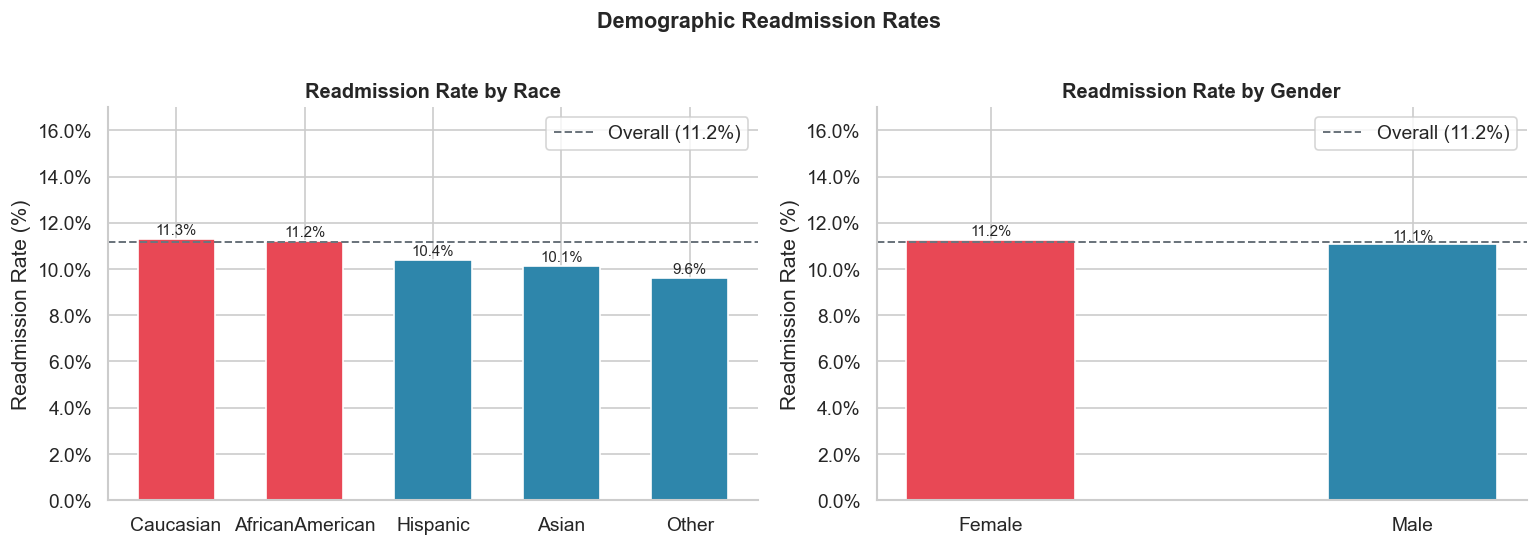

Readmission rate by race:
           race     mean  count
      Caucasian 0.112906  76099
AfricanAmerican 0.112181  19210
       Hispanic 0.104075   2037
          Asian 0.101404    641
          Other 0.096282   1506

Readmission rate by gender:
gender     mean  count
Female 0.112452  54708
  Male 0.110615  47055


In [7]:
# ── Race & Gender readmission rates ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Race
race_rate = df[df['race'] != 'Unknown'].groupby('race')['readmitted_binary'].agg(['mean','count']).reset_index()
race_rate = race_rate.sort_values('mean', ascending=False)
overall_rate = df['readmitted_binary'].mean()

colors_race = [RED if v > overall_rate else BLUE for v in race_rate['mean']]
axes[0].bar(race_rate['race'], race_rate['mean']*100, color=colors_race, edgecolor='white', width=0.6)
axes[0].axhline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Race')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()
axes[0].set_ylim(0, 17)
for i, row in enumerate(race_rate.itertuples()):
    axes[0].text(i, row.mean*100 + 0.2, f'{row.mean*100:.1f}%', ha='center', fontsize=9)

# Gender
gender_rate = df[~df['gender'].isin(['Unknown/Invalid'])].groupby('gender')['readmitted_binary'].agg(['mean','count']).reset_index()
colors_gen = [RED if v > overall_rate else BLUE for v in gender_rate['mean']]
axes[1].bar(gender_rate['gender'], gender_rate['mean']*100, color=colors_gen, edgecolor='white', width=0.4)
axes[1].axhline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Gender')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
axes[1].set_ylim(0, 17)
for i, row in enumerate(gender_rate.itertuples()):
    axes[1].text(i, row.mean*100 + 0.2, f'{row.mean*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Demographic Readmission Rates', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Readmission rate by race:")
print(race_rate[['race','mean','count']].to_string(index=False))
print()
print("Readmission rate by gender:")
print(gender_rate[['gender','mean','count']].to_string(index=False))

> **Finding:** Race and gender show minimal variation in readmission rates (all within 11–11.3%). The dataset is predominantly Caucasian (75%). These variables are unlikely to be strong standalone model features, though they may matter in interaction with clinical variables.

---
## 5. Admission & Discharge Patterns

How patients enter and leave the hospital reveals much about their clinical trajectory. Emergency admissions and transfers to skilled nursing facilities signal higher acuity  -  both of which are associated with readmission risk.

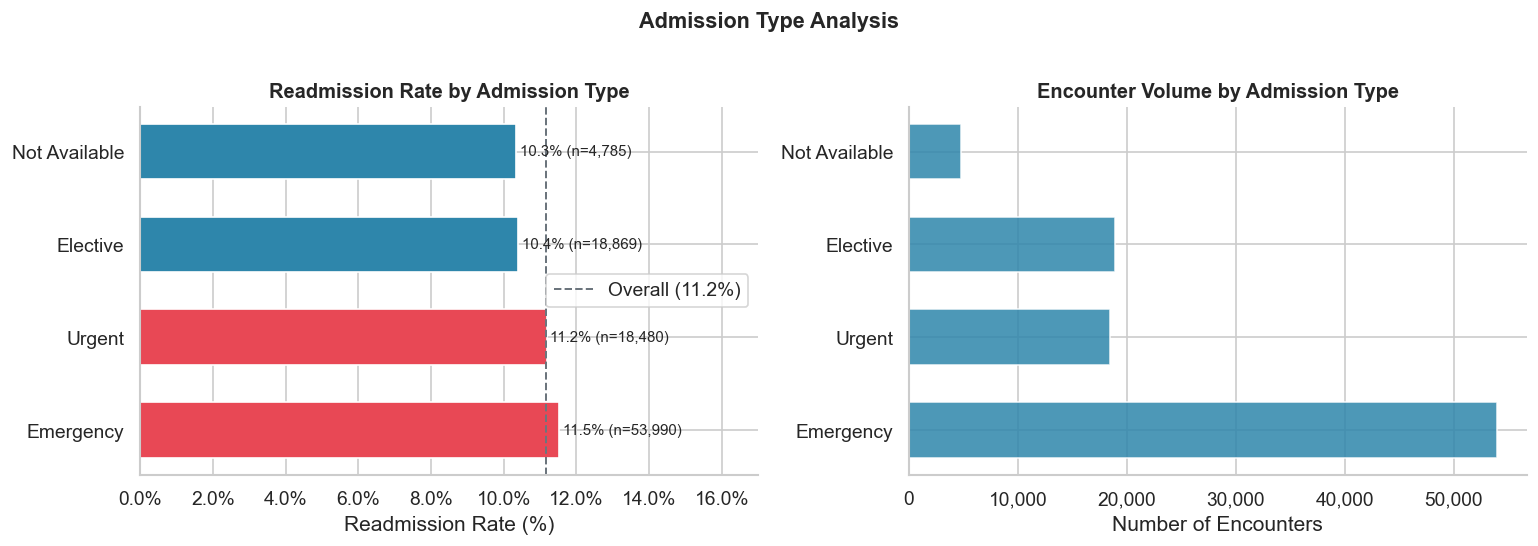

In [8]:
# ── Admission type readmission rates ─────────────────────────────────────────
admit_rate = df[~df['admission_type'].isin(['Not Mapped','NULL'])].groupby('admission_type')['readmitted_binary'].agg(['mean','count']).reset_index()
admit_rate = admit_rate[admit_rate['count'] > 50].sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors_admit = [RED if v > overall_rate else BLUE for v in admit_rate['mean']]
axes[0].barh(admit_rate['admission_type'], admit_rate['mean']*100,
             color=colors_admit, edgecolor='white', height=0.6)
axes[0].axvline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
axes[0].set_xlabel('Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Admission Type')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()
for i, row in enumerate(admit_rate.itertuples()):
    axes[0].text(row.mean*100 + 0.1, i, f'{row.mean*100:.1f}% (n={row.count:,})', va='center', fontsize=9)
axes[0].set_xlim(0, 17)

# Volume
axes[1].barh(admit_rate['admission_type'], admit_rate['count'],
             color=BLUE, edgecolor='white', height=0.6, alpha=0.85)
axes[1].set_xlabel('Number of Encounters')
axes[1].set_title('Encounter Volume by Admission Type')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Admission Type Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

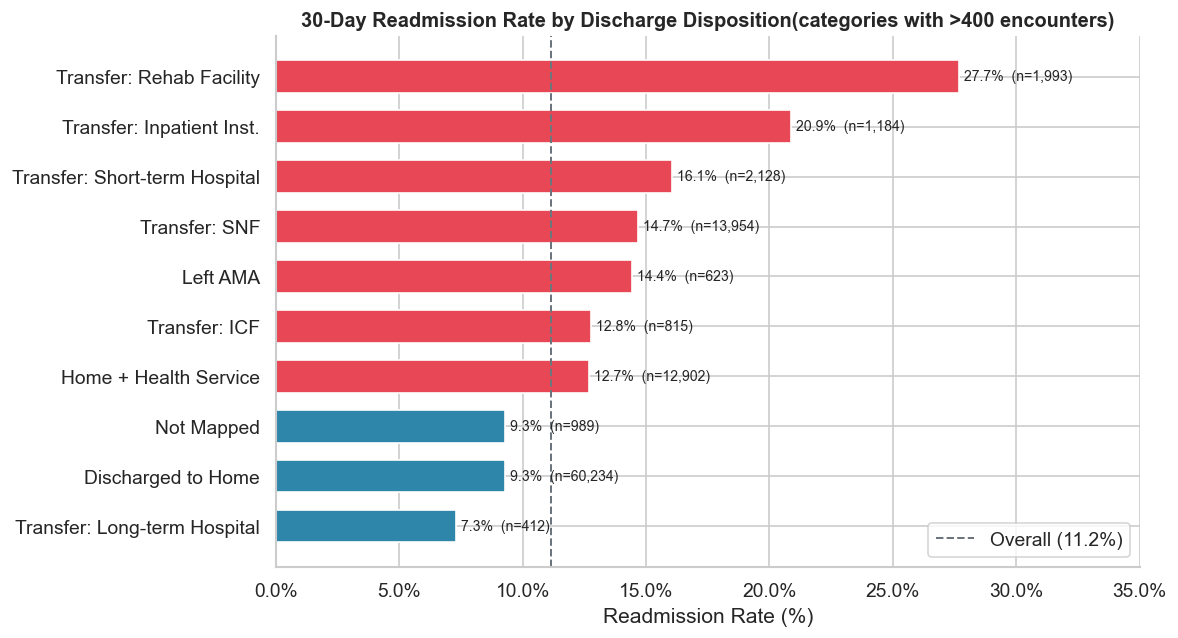

In [9]:
# ── Discharge disposition (top categories by volume) ─────────────────────────
disp_rate = df.groupby('discharge_disposition')['readmitted_binary'].agg(['mean','count']).reset_index()
disp_rate = disp_rate[disp_rate['count'] > 400].sort_values('mean', ascending=False).head(10)

# Shorten long labels
label_map = {
    'Discharged/transferred to another rehab fac including rehab units of a hospital .': 'Transfer: Rehab Facility',
    'Discharged/transferred to another type of inpatient care institution': 'Transfer: Inpatient Inst.',
    'Discharged/transferred to another short term hospital': 'Transfer: Short-term Hospital',
    'Discharged/transferred to SNF': 'Transfer: SNF',
    'Left AMA': 'Left AMA',
    'Discharged/transferred to ICF': 'Transfer: ICF',
    'Discharged/transferred to home with home health service': 'Home + Health Service',
    'Not Mapped': 'Not Mapped',
    'Discharged to home': 'Discharged to Home',
    'Discharged/transferred to a long term care hospital.': 'Transfer: Long-term Hospital',
}
disp_rate['label'] = disp_rate['discharge_disposition'].map(label_map).fillna(disp_rate['discharge_disposition'])

fig, ax = plt.subplots(figsize=(10, 5.5))
colors_disp = [RED if v > overall_rate else BLUE for v in disp_rate['mean']]
bars = ax.barh(disp_rate['label'], disp_rate['mean']*100,
               color=colors_disp, edgecolor='white', height=0.65)
ax.axvline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
ax.set_xlabel('Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Discharge Disposition(categories with >400 encounters)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for bar, row in zip(bars, disp_rate.itertuples()):
    ax.text(row.mean*100 + 0.2, bar.get_y() + bar.get_height()/2,
            f'{row.mean*100:.1f}%  (n={row.count:,})', va='center', fontsize=8.5)
ax.set_xlim(0, 35)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Finding:** Patients transferred to **rehabilitation or other inpatient facilities** have 2–2.5× the average readmission rate  -  these are the sickest patients. Patients simply **discharged to home** have the lowest readmission rate (9.3%), below the overall average. This is a clinically meaningful signal for risk stratification.

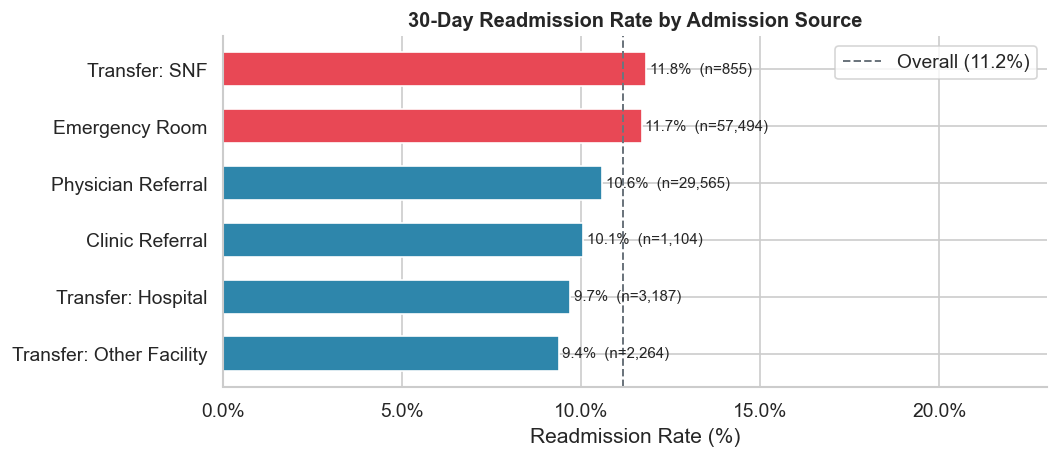

In [10]:
# ── Admission source readmission rates ───────────────────────────────────────
source_rate = df.groupby('admission_source')['readmitted_binary'].agg(['mean','count']).reset_index()
source_rate = source_rate[source_rate['count'] > 200].sort_values('mean', ascending=False)

source_labels = {
    ' Emergency Room': 'Emergency Room',
    ' Physician Referral': 'Physician Referral',
    'Transfer from a hospital': 'Transfer: Hospital',
    ' Transfer from another health care facility': 'Transfer: Other Facility',
    'Clinic Referral': 'Clinic Referral',
    ' Transfer from a Skilled Nursing Facility (SNF)': 'Transfer: SNF',
    'HMO Referral': 'HMO Referral',
}
source_rate['label'] = source_rate['admission_source'].map(source_labels).fillna(source_rate['admission_source'].str.strip())

fig, ax = plt.subplots(figsize=(9, 4))
colors_src = [RED if v > overall_rate else BLUE for v in source_rate['mean']]
bars = ax.barh(source_rate['label'], source_rate['mean']*100,
               color=colors_src, edgecolor='white', height=0.6)
ax.axvline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
ax.set_xlabel('Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Admission Source')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for bar, row in zip(bars, source_rate.itertuples()):
    ax.text(row.mean*100 + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row.mean*100:.1f}%  (n={row.count:,})', va='center', fontsize=9)
ax.set_xlim(0, 23)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Finding:** Patients admitted from the **Emergency Room** (the largest group at 57k) have slightly above-average readmission rates (11.7%), while **HMO referrals** have notably higher rates (15.5%)  -  possibly reflecting a sicker managed-care population.

---
## 6. Clinical Complexity

Clinical load  -  how many diagnoses, medications, and procedures a patient has  -  reflects disease burden. Higher complexity generally corresponds to higher readmission risk.

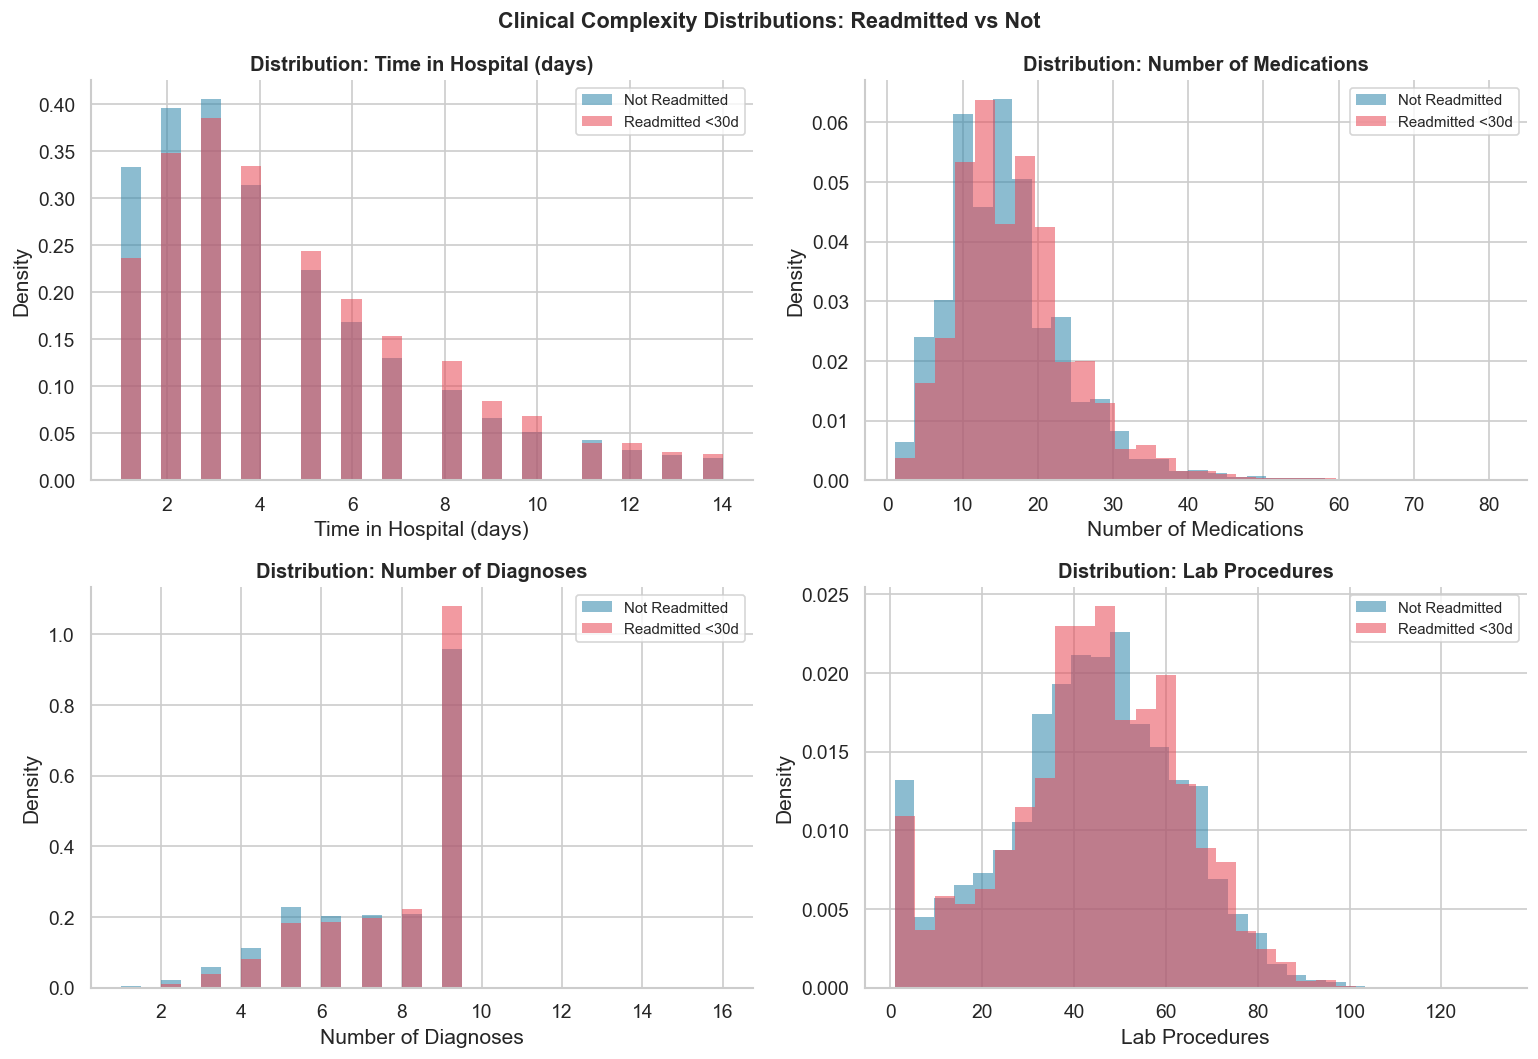

In [11]:
# ── Time in hospital & medication load distributions ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

plot_specs = [
    ('time_in_hospital', 'Time in Hospital (days)', axes[0,0]),
    ('num_medications',  'Number of Medications',   axes[0,1]),
    ('number_diagnoses', 'Number of Diagnoses',     axes[1,0]),
    ('num_lab_procedures','Lab Procedures',         axes[1,1]),
]

for col, xlabel, ax in plot_specs:
    for label, val, color in [('Not Readmitted', 0, BLUE), ('Readmitted <30d', 1, RED)]:
        subset = df[df['readmitted_binary'] == val][col]
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=label,
                density=True, edgecolor='none')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution: {xlabel}')
    ax.legend(fontsize=9)

plt.suptitle('Clinical Complexity Distributions: Readmitted vs Not', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

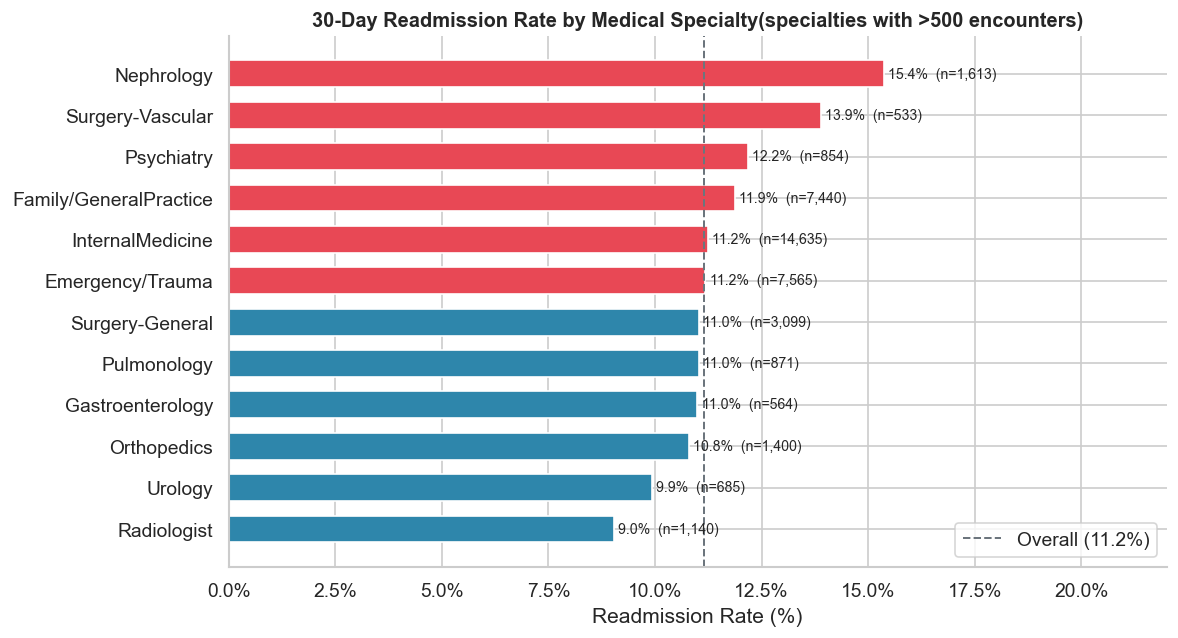

In [13]:
# ── Medical specialty readmission rates ──────────────────────────────────────
spec_rate = df[df['medical_specialty'] != 'Unknown'].groupby('medical_specialty')['readmitted_binary'].agg(['mean','count']).reset_index()
spec_rate = spec_rate[spec_rate['count'] > 500].sort_values('mean', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5.5))
colors_spec = [RED if v > overall_rate else BLUE for v in spec_rate['mean']]
bars = ax.barh(spec_rate['medical_specialty'], spec_rate['mean']*100,
               color=colors_spec, edgecolor='white', height=0.65)
ax.axvline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
ax.set_xlabel('Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Medical Specialty(specialties with >500 encounters)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for bar, row in zip(bars, spec_rate.itertuples()):
    ax.text(row.mean*100 + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row.mean*100:.1f}%  (n={row.count:,})', va='center', fontsize=8.5)
ax.set_xlim(0, 22)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Finding:** **Nephrology** has the highest readmission rate (15.4%) among high-volume specialties, followed by Vascular Surgery (13.9%) and Psychiatry (12.2%). **Cardiology** is notably below average (7.9%)  -  likely reflecting well-structured cardiac care protocols. `medical_specialty` will be a useful model feature.

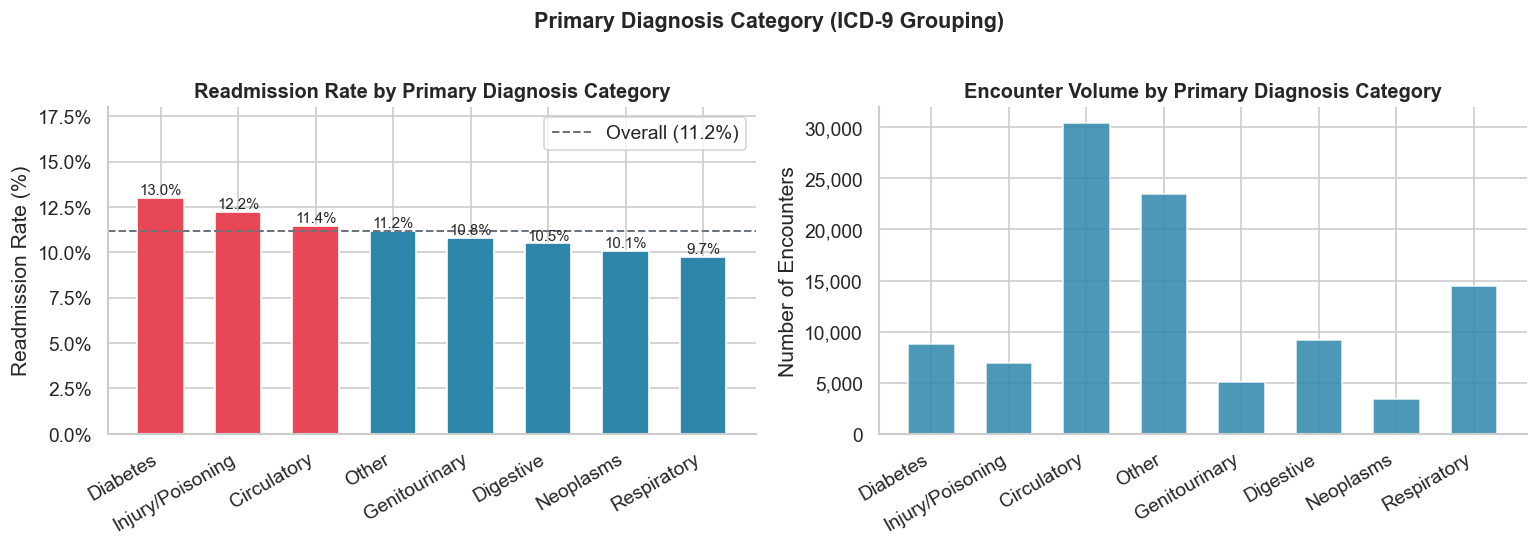

  diag1_category     mean  count
        Diabetes 0.129839   8757
Injury/Poisoning 0.122455   6974
     Circulatory 0.114499  30437
           Other 0.111571  23456
   Genitourinary 0.108113   5078
       Digestive 0.104909   9208
       Neoplasms 0.100786   3433
     Respiratory 0.097275  14423


In [14]:
# ── Primary diagnosis category analysis ─────────────────────────────────────
def categorise_diag(code):
    code = str(code)
    try:
        val = float(code.split('.')[0])
        if 390 <= val <= 459 or val == 785: return 'Circulatory'
        if 460 <= val <= 519 or val == 786: return 'Respiratory'
        if code.startswith('250'):          return 'Diabetes'
        if 800 <= val <= 999:               return 'Injury/Poisoning'
        if 140 <= val <= 239:               return 'Neoplasms'
        if 520 <= val <= 579:               return 'Digestive'
        if 580 <= val <= 629:               return 'Genitourinary'
        return 'Other'
    except:
        return 'Other'

df['diag1_category'] = df['diag_1'].apply(categorise_diag)
diag_rate = df.groupby('diag1_category')['readmitted_binary'].agg(['mean','count']).reset_index()
diag_rate = diag_rate.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors_diag = [RED if v > overall_rate else BLUE for v in diag_rate['mean']]
axes[0].bar(diag_rate['diag1_category'], diag_rate['mean']*100,
            color=colors_diag, edgecolor='white', width=0.6)
axes[0].axhline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Primary Diagnosis Category')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()
axes[0].set_xticklabels(diag_rate['diag1_category'], rotation=30, ha='right')
for i, row in enumerate(diag_rate.itertuples()):
    axes[0].text(i, row.mean*100 + 0.2, f'{row.mean*100:.1f}%', ha='center', fontsize=9)
axes[0].set_ylim(0, 18)

axes[1].bar(diag_rate['diag1_category'], diag_rate['count'],
            color=BLUE, edgecolor='white', width=0.6, alpha=0.85)
axes[1].set_ylabel('Number of Encounters')
axes[1].set_title('Encounter Volume by Primary Diagnosis Category')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].set_xticklabels(diag_rate['diag1_category'], rotation=30, ha='right')

plt.suptitle('Primary Diagnosis Category (ICD-9 Grouping)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(diag_rate[['diag1_category','mean','count']].to_string(index=False))

> **Finding:** Encounters where **Diabetes is the primary diagnosis** (ICD-9 250.xx) have the highest readmission rate (13.0%)  -  16% above the overall average. Circulatory diagnoses are the largest group (30k encounters) and also above average (11.5%), consistent with the comorbidity burden typical of diabetic patients.

---
## 7. Diabetes Medication Management

Medication management is a domain-specific signal. Poorly controlled diabetes  -  evidenced by high glucose, elevated HbA1c, or frequent medication adjustments  -  should correlate with worse outcomes. This section tests those hypotheses.

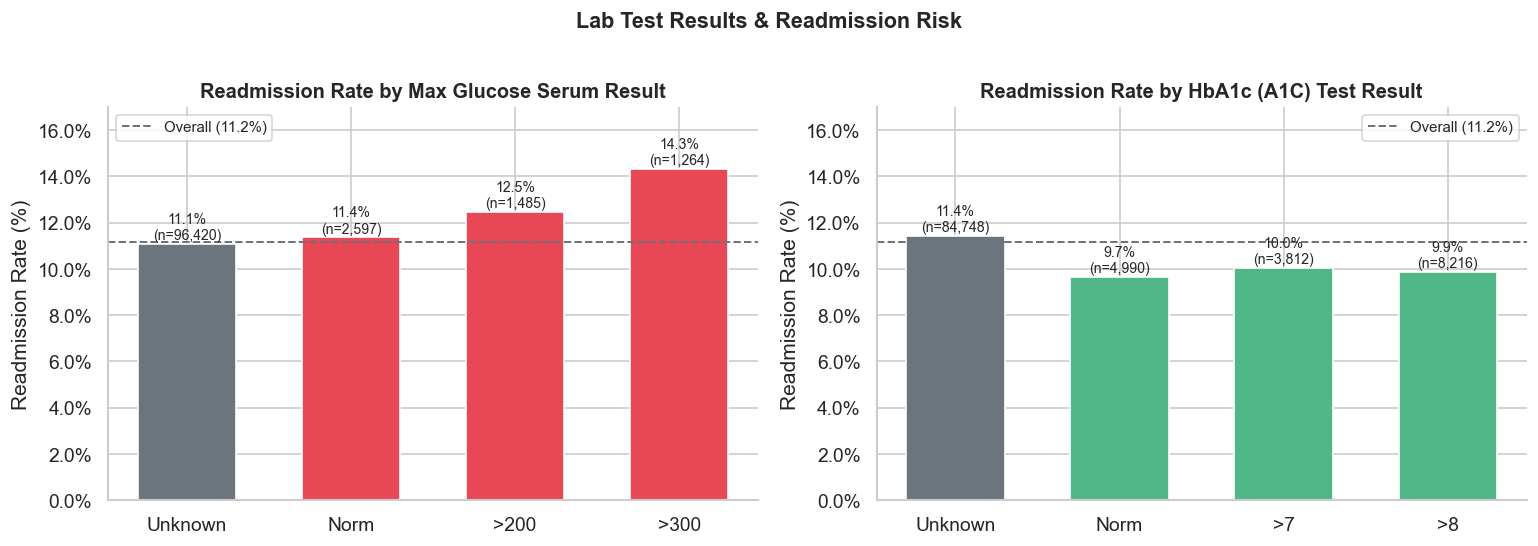

In [15]:
# ── Glucose & HbA1c test results ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, title in [
    (axes[0], 'max_glu_serum', 'Max Glucose Serum Result'),
    (axes[1], 'A1Cresult',     'HbA1c (A1C) Test Result'),
]:
    rate = df.groupby(col)['readmitted_binary'].agg(['mean','count']).reset_index()
    order = ['Unknown', 'Norm', '>7', '>8'] if col == 'A1Cresult' else ['Unknown', 'Norm', '>200', '>300']
    order = [o for o in order if o in rate[col].values]
    rate = rate.set_index(col).loc[order].reset_index()

    colors_lab = [GRAY if v == 'Unknown' else (RED if rate.loc[rate[col]==v,'mean'].values[0] > overall_rate else GREEN)
                  for v in rate[col]]
    bars = ax.bar(rate[col], rate['mean']*100, color=colors_lab, edgecolor='white', width=0.6)
    ax.axhline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
    ax.set_ylabel('Readmission Rate (%)')
    ax.set_title(f'Readmission Rate by {title}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=9)
    ax.set_ylim(0, 17)
    for bar, row in zip(bars, rate.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{row.mean*100:.1f}%\n(n={row.count:,})', ha='center', fontsize=8.5)

plt.suptitle('Lab Test Results & Readmission Risk', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Finding:** Counter-intuitively, patients with **documented elevated glucose or A1C are not at higher readmission risk** than those with normal results. Patients with **no test recorded (Unknown, ~85–94% of cases)** have slightly higher readmission rates. This likely reflects a selection effect: sicker patients who arrive via ER often don't receive elective lab tests, but are at higher baseline risk.

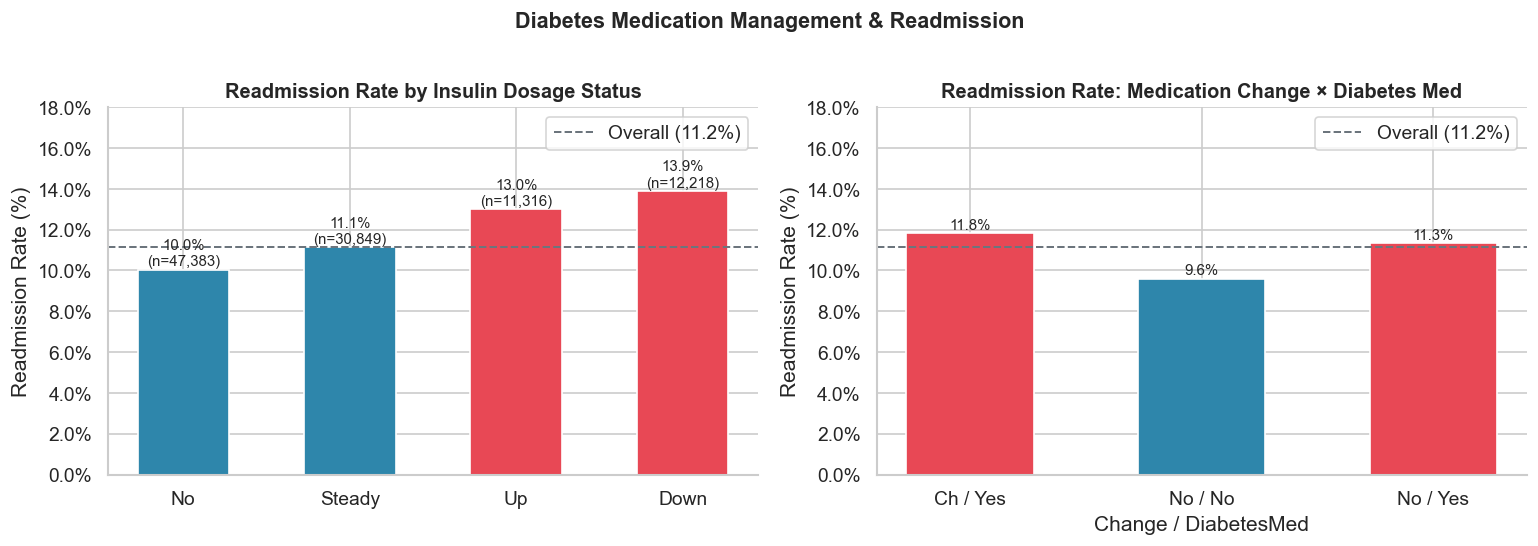

In [16]:
# ── Insulin & medication change ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Insulin
insulin_rate = df.groupby('insulin')['readmitted_binary'].agg(['mean','count']).reset_index()
insulin_order = ['No', 'Steady', 'Up', 'Down']
insulin_rate = insulin_rate.set_index('insulin').loc[insulin_order].reset_index()
colors_ins = [RED if v > overall_rate else BLUE for v in insulin_rate['mean']]
bars = axes[0].bar(insulin_rate['insulin'], insulin_rate['mean']*100,
                   color=colors_ins, edgecolor='white', width=0.55)
axes[0].axhline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Insulin Dosage Status')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()
axes[0].set_ylim(0, 18)
for bar, row in zip(bars, insulin_rate.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{row.mean*100:.1f}%\n(n={row.count:,})', ha='center', fontsize=9)

# Medication change + diabetesMed
change_rate = df.groupby(['change','diabetesMed'])['readmitted_binary'].mean().reset_index()
change_rate['group'] = change_rate['change'] + ' / ' + change_rate['diabetesMed']
colors_ch = [RED if v > overall_rate else BLUE for v in change_rate['readmitted_binary']]
bars2 = axes[1].bar(change_rate['group'], change_rate['readmitted_binary']*100,
                    color=colors_ch, edgecolor='white', width=0.55)
axes[1].axhline(overall_rate*100, color=GRAY, linestyle='--', linewidth=1.2, label=f'Overall ({overall_rate*100:.1f}%)')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate: Medication Change × Diabetes Med')
axes[1].set_xlabel('Change / DiabetesMed')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
axes[1].set_ylim(0, 18)
for bar, row in zip(bars2, change_rate.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{row.readmitted_binary*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Diabetes Medication Management & Readmission', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# ── Key medications: usage rate & readmission impact ─────────────────────────
meds_of_interest = ['insulin', 'metformin', 'glipizide', 'glyburide',
                     'glimepiride', 'pioglitazone', 'rosiglitazone', 'repaglinide']

med_summary = []
for med in meds_of_interest:
    used   = df[df[med] != 'No']
    unused = df[df[med] == 'No']
    med_summary.append({
        'Medication':       med.capitalize(),
        'Usage Rate (%)':   len(used) / len(df) * 100,
        'Readmit if Used':  used['readmitted_binary'].mean() * 100,
        'Readmit if Not':   unused['readmitted_binary'].mean() * 100,
        'Difference (pp)':  (used['readmitted_binary'].mean() - unused['readmitted_binary'].mean()) * 100,
    })

med_df = pd.DataFrame(med_summary).set_index('Medication').round(2)
print("Medication usage rates and readmission impact:")
print(med_df.to_string())

Medication usage rates and readmission impact:
               Usage Rate (%)  Readmit if Used  Readmit if Not  Difference (pp)
Medication                                                                     
Insulin                 53.44            12.14           10.04             2.10
Metformin               19.64             9.70           11.52            -1.82
Glipizide               12.47            11.45           11.12             0.33
Glyburide               10.47            10.63           11.22            -0.59
Glimepiride              5.10            10.21           11.21            -1.00
Pioglitazone             7.20            10.56           11.21            -0.64
Rosiglitazone            6.25            10.45           11.21            -0.76
Repaglinide              1.51            13.32           11.13             2.19


> **Finding:** Insulin is used in 53% of encounters and is associated with a **+2pp higher readmission rate**  -  insulin-dependent patients are more severely ill. **Metformin use is associated with lower readmission** (−1.8pp), consistent with its role as first-line therapy for well-controlled type 2 diabetes. Medication dosage changes ('Ch') are associated with slightly higher readmission, suggesting active medication management occurs in more complex cases.

---
## 8. Key Findings Summary & Modelling Implications

### What drives 30-day readmission in this dataset?

| Rank | Feature | Finding | Implication |
|---|---|---|---|
| 1 | **Prior inpatient stays** | 2.2× higher in readmitted patients; readmission rate rises from 7% → 28%+ with more prior stays | Strongest single feature  -  must be included |
| 2 | **Prior ER visits** | 2.0× higher in readmitted patients | Include as-is; consider combining with inpatient into a "utilisation score" |
| 3 | **Discharge disposition** | Transfer to rehab/inpatient facilities: 21–28% readmission vs 9% for home discharge | High-cardinality categorical  -  encode carefully |
| 4 | **Medical specialty** | Nephrology (15.4%), Vascular Surgery (13.9%) vs Cardiology (7.9%) | Encode with target encoding or grouping |
| 5 | **Primary diagnosis category** | Diabetes as primary diagnosis: 13% vs 10.7% average | Group ICD-9 codes into clinical categories |
| 6 | **Insulin use** | +2pp readmission vs non-insulin patients | Binary feature or encode dosage direction |
| 7 | **Medication change** | Patients with medication changes slightly higher risk | Binary indicator |
| 8 | **Metformin use** | −1.8pp protective effect | Feature worth including |
| 9 | **Clinical complexity** | Modest differences (5–10% higher) in medications, diagnoses, hospital stay | Useful but secondary |
| 10 | **Demographics (age, race, gender)** | Minimal variation  -  weak standalone predictors | May matter in interactions |

### Class Imbalance Strategy
The 8:1 class imbalance requires:
- Use `class_weight='balanced'` in tree-based models
- Evaluate on **Recall** and **ROC-AUC**, not accuracy
- Apply probability threshold tuning after training

### Feature Engineering Recommendations
- Create a **prior utilisation score**: `number_inpatient + number_emergency`
- **Group ICD-9 codes** into clinical categories (Circulatory, Diabetes, Respiratory, etc.)
- **Binary flags**: `insulin_used`, `metformin_used`, `med_change`
- **Discharge risk tier**: home (low), SNF/home health (medium), transfer (high)

In [18]:
# ── Final summary statistics table ───────────────────────────────────────────
summary_stats = {
    'Total encounters':          f"{len(df):,}",
    'Readmitted <30d':           f"{df['readmitted_binary'].sum():,} ({df['readmitted_binary'].mean()*100:.1f}%)",
    'Mean age':                  f"{df['age_numeric'].mean():.1f} years",
    'Mean time in hospital':     f"{df['time_in_hospital'].mean():.1f} days",
    'Mean prior inpatient stays':f"{df['number_inpatient'].mean():.2f}",
    'Insulin-dependent (%)':     f"{(df['insulin'] != 'No').mean()*100:.1f}%",
    'On any diabetes med (%)':   f"{(df['diabetesMed'] == 'Yes').mean()*100:.1f}%",
    'Emergency admissions (%)':  f"{(df['admission_type'] == 'Emergency').mean()*100:.1f}%",
    'Discharged to home (%)':    f"{(df['discharge_disposition'] == 'Discharged to home').mean()*100:.1f}%",
}

print("=" * 50)
print("  DATASET SUMMARY")
print("=" * 50)
for k, v in summary_stats.items():
    print(f"  {k:<32} {v}")
print("=" * 50)

  DATASET SUMMARY
  Total encounters                 101,766
  Readmitted <30d                  11,357 (11.2%)
  Mean age                         66.0 years
  Mean time in hospital            4.4 days
  Mean prior inpatient stays       0.64
  Insulin-dependent (%)            53.4%
  On any diabetes med (%)          77.0%
  Emergency admissions (%)         53.1%
  Discharged to home (%)           59.2%
